#  Soybean Yield Prediction Pipeline — v4
**Google Colab — Full Pipeline**

Built on the standardized (soil / micro-climate-weather / target-unit) schema
from v5. This version focuses on the modeling step:

1. **Model comparison** — Ridge, Lasso, Random Forest, **Extra Trees**, XGBoost,
   all evaluated with the same 5-fold temporal CV.
2. **Hyperparameter search** — a randomized search over the tree ensembles
   using the temporal folds as the CV splitter (not a random K-fold, since
   yield data is autocorrelated by year/region).
3. **Final model = stacked ensemble** — Extra Trees + Random Forest + XGBoost
   as base learners, Ridge as the meta-learner. Stacking is used because the
   three trees make *different kinds* of errors (Extra Trees' extra
   randomness decorrelates it from RF/XGB), so blending them tends to beat
   any single tree model on soil/weather tabular data like this.

The country-config / standardization layer from v5 (Steps 1–4) is unchanged —
this version just swaps out Steps 6–9 for a stronger modeling section.


##  STEP 0 — Setup: Install Libraries & Import

In [ ]:
# Install XGBoost (pre-installed on Colab but ensuring latest)
!pip install xgboost --quiet

import warnings
import json
import os
import re
from dataclasses import dataclass, field
from typing import Callable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.cluster import KMeans
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
pd.set_option('display.max_columns', 20)

ARTIFACT_DIR = '/content/artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(' All libraries imported successfully.')

✅ All libraries imported successfully.


##  STEP 1 — Country Configuration

Single source of truth for the raw → standardized column mapping (soil, weekly
micro-climate/weather, region, target unit). Kept generic in structure, but
only `USA` is active — no Sri Lanka work this round.

In [ ]:
@dataclass
class CountryConfig:
    country_code: str
    raw_path: str
    weather_vars: dict                      # {std_name: raw_prefix}
    weekly_col_pattern: Callable[[str, int], str]
    growing_season_weeks: list
    soil_vars: dict                         # {std_name: raw_prefix}
    soil_depth_regex: Callable[[str], "re.Pattern"]
    region_col: str
    lat_col: str
    lon_col: str
    year_col: str
    raw_target_col: str
    target_unit_to_kg_per_ha: float
    valid_target_range_kg_ha: tuple
    id_cols_to_drop: list = field(default_factory=list)
    baseline_year: int = 1980
    fixed_folds: list = field(default_factory=list)


USA_CONFIG = CountryConfig(
    country_code="USA",
    raw_path="khaki_multi_crop_yield.csv",
    weather_vars={
        "precipitation": "W_1", "solar_radiation": "W_2",
        "snow_water_equivalent": "W_3", "maximum_temperature": "W_4",
        "minimum_temperature": "W_5", "vapor_pressure": "W_6",
    },
    weekly_col_pattern=lambda prefix, week: f"{prefix}_{week}",
    growing_season_weeks=list(range(14, 40)),   # weeks 14-39 ~ May-Sep
    soil_vars={
        "bulk_density": "bdod", "cation_exchange_capacity": "cec",
        "coarse_fragments": "cfvo", "clay_content": "clay",
        "total_nitrogen": "nitrogen", "organic_carbon_density": "ocd",
        "organic_carbon_stocks": "ocs", "soil_ph": "phh2o",
        "sand_content": "sand", "silt_content": "silt",
        "soil_organic_carbon": "soc",
    },
    soil_depth_regex=lambda prefix: re.compile(rf"^{prefix}_mean_(.+)$"),
    region_col="State", lat_col="lat", lon_col="lng", year_col="year",
    raw_target_col="soybean_yield",
    target_unit_to_kg_per_ha=67.25,   # 1 Bu/Acre soybean ≈ 67.25 kg/ha
    valid_target_range_kg_ha=(5 * 67.25, 100 * 67.25),
    id_cols_to_drop=["corn_yield", "winter_wheat_yield"],
    baseline_year=1980,
    fixed_folds=[
        {"train_max_year": 2013, "test_year": 2014},
        {"train_max_year": 2014, "test_year": 2015},
        {"train_max_year": 2015, "test_year": 2016},
        {"train_max_year": 2016, "test_year": 2017},
        {"train_max_year": 2017, "test_year": 2018},
    ],
)

cfg = USA_CONFIG
print(f"Active config: {cfg.country_code}  ->  {cfg.raw_path}")

Active config: USA  ->  khaki_multi_crop_yield.csv


##  STEP 2 — Load Raw Data

In [ ]:
import os

# Point this at the file as it sits in Colab (left-hand Files pane).
# If you used the Files pane upload icon, it lands in /content/ by default.
RAW_PATH = f"/content/{cfg.raw_path}"

if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(
        f"Could not find {RAW_PATH}. Check the exact filename/path in the "
        f"Colab Files pane (left sidebar) and update RAW_PATH above to match."
    )

raw = pd.read_csv(RAW_PATH)
print(f"Loaded {RAW_PATH}: {len(raw):,} rows x {raw.shape[1]} columns")


Loaded /content/khaki_multi_crop_yield.csv: 25,306 rows x 401 columns


##  STEP 3 — Standardize + Clean

STEP 3 — Standardizing & Cleaning
  Dropped 0 rows with missing target. Remaining: 25306
  Dropped 0 exact duplicate rows.
  Removed 0 extreme yield outliers (IQR x3 per region).
  Clipped to [336, 6725] kg/ha; removed 2 rows. Final: 25304


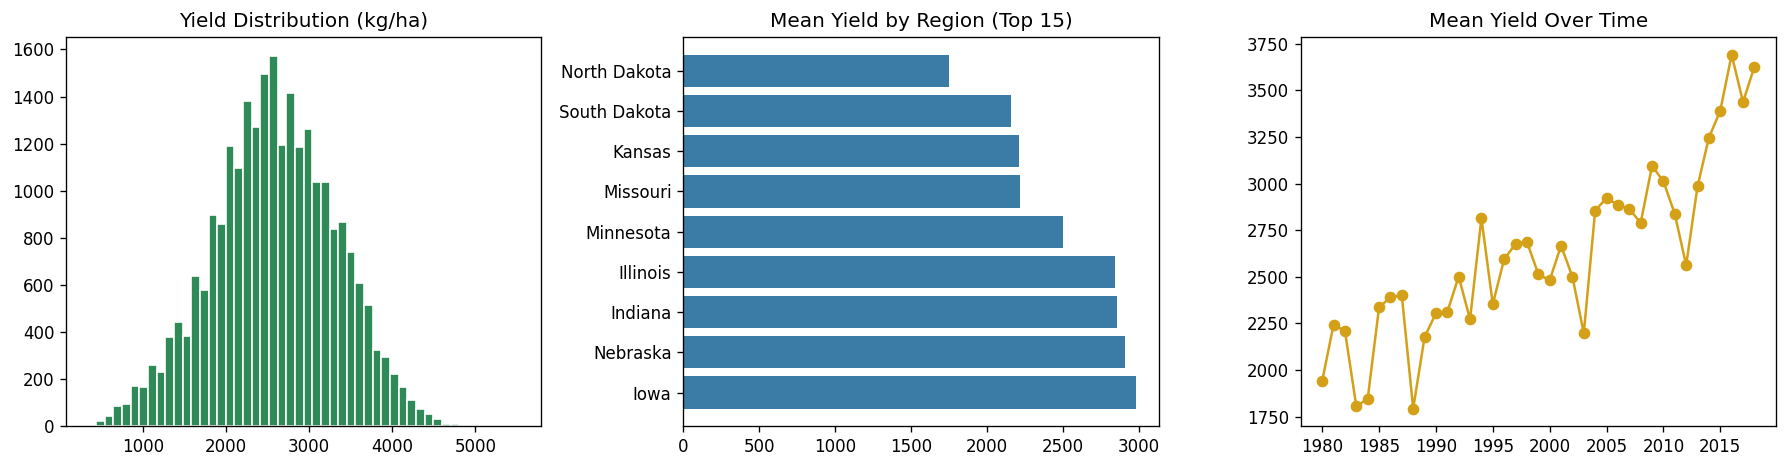

In [ ]:
def standardize_and_clean(df_raw: pd.DataFrame, cfg: CountryConfig) -> pd.DataFrame:
    print('=' * 65); print('STEP 3 — Standardizing & Cleaning'); print('=' * 65)
    df = df_raw.copy()
    df = df.drop(columns=cfg.id_cols_to_drop, errors='ignore')

    df['yield_kg_ha'] = df[cfg.raw_target_col] * cfg.target_unit_to_kg_per_ha
    before = len(df)
    df = df.dropna(subset=['yield_kg_ha'])
    print(f'  Dropped {before - len(df)} rows with missing target. Remaining: {len(df)}')

    before = len(df)
    df = df.drop_duplicates()
    print(f'  Dropped {before - len(df)} exact duplicate rows.')

    df['region'] = df[cfg.region_col].astype(str).str.strip().str.title()
    df['latitude'] = df[cfg.lat_col]
    df['longitude'] = df[cfg.lon_col]
    df['obs_year'] = df[cfg.year_col]
    df['country'] = cfg.country_code

    def iqr_outlier_mask(series, factor=3.0):
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        return (series >= q1 - factor * iqr) & (series <= q3 + factor * iqr)

    before = len(df)
    mask = df.groupby('region')['yield_kg_ha'].transform(iqr_outlier_mask)
    df = df[mask].copy()
    print(f'  Removed {before - len(df)} extreme yield outliers (IQR x3 per region).')

    lo, hi = cfg.valid_target_range_kg_ha
    before = len(df)
    df = df[(df['yield_kg_ha'] >= lo) & (df['yield_kg_ha'] <= hi)]
    print(f'  Clipped to [{lo:.0f}, {hi:.0f}] kg/ha; removed {before - len(df)} rows. Final: {len(df)}')
    return df


df_clean = standardize_and_clean(raw, cfg)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_clean['yield_kg_ha'], bins=50, color='#2E8B57', edgecolor='white')
axes[0].set_title('Yield Distribution (kg/ha)')
yield_by_region = df_clean.groupby('region')['yield_kg_ha'].mean().sort_values(ascending=False).head(15)
axes[1].barh(yield_by_region.index, yield_by_region.values, color='#3A7CA5')
axes[1].set_title('Mean Yield by Region (Top 15)')
yield_by_year = df_clean.groupby('obs_year')['yield_kg_ha'].mean()
axes[2].plot(yield_by_year.index, yield_by_year.values, marker='o', color='#D4A017')
axes[2].set_title('Mean Yield Over Time')
plt.tight_layout()
plt.savefig('/content/eda_overview.png', bbox_inches='tight')
plt.show()

##  STEP 4 — Feature Engineering (Soil + Micro-Climate/Weather)

Final feature set is deliberately built from exactly the three signal groups
the model is meant to learn from: **soil properties**, **micro-climate /
weekly weather aggregates**, and **location/time context** (lat/lon/region/year)
needed to situate the soil+weather readings. No production/economic columns
(area planted, expenses, etc.) are included — those are outcomes, not
predictors, and including them would leak information.

In [ ]:
def engineer_features(df: pd.DataFrame, cfg: CountryConfig, region_encoder: Optional[LabelEncoder] = None):
    print('=' * 65); print('STEP 4 — Feature Engineering'); print('=' * 65)
    feat = df.copy()

    # Growing-season + annual weather aggregates (micro-climate signal)
    for std_name, prefix in cfg.weather_vars.items():
        all_week_cols = [cfg.weekly_col_pattern(prefix, w) for w in range(1, 53)
                          if cfg.weekly_col_pattern(prefix, w) in feat.columns]
        gs_cols = [cfg.weekly_col_pattern(prefix, w) for w in cfg.growing_season_weeks
                   if cfg.weekly_col_pattern(prefix, w) in feat.columns]
        if gs_cols:
            feat[f'growing_season_{std_name}_mean'] = feat[gs_cols].mean(axis=1)
            feat[f'growing_season_{std_name}_sum']  = feat[gs_cols].sum(axis=1)
            feat[f'growing_season_{std_name}_std']  = feat[gs_cols].std(axis=1)
        if all_week_cols:
            feat[f'annual_{std_name}_mean'] = feat[all_week_cols].mean(axis=1)

    # Weather interaction terms — capture compounding stress (heat x dryness, etc.)
    if {'growing_season_maximum_temperature_mean', 'growing_season_minimum_temperature_mean'} <= set(feat.columns):
        feat['growing_season_diurnal_temperature_range'] = (
            feat['growing_season_maximum_temperature_mean'] - feat['growing_season_minimum_temperature_mean'])
    if {'growing_season_precipitation_mean', 'growing_season_solar_radiation_mean'} <= set(feat.columns):
        feat['growing_season_precipitation_x_solar_radiation'] = (
            feat['growing_season_precipitation_mean'] * feat['growing_season_solar_radiation_mean'])
    if {'growing_season_vapor_pressure_mean', 'growing_season_maximum_temperature_mean'} <= set(feat.columns):
        feat['growing_season_vapor_pressure_x_max_temperature'] = (
            feat['growing_season_vapor_pressure_mean'] * feat['growing_season_maximum_temperature_mean'])
    # Heat-stress proxy: degree-days above 30C across growing season, if max-temp weeks exist
    max_temp_prefix = cfg.weather_vars.get('maximum_temperature')
    if max_temp_prefix:
        gs_max_cols = [cfg.weekly_col_pattern(max_temp_prefix, w) for w in cfg.growing_season_weeks
                       if cfg.weekly_col_pattern(max_temp_prefix, w) in feat.columns]
        if gs_max_cols:
            feat['growing_season_heat_stress_degree_days'] = (feat[gs_max_cols] - 30).clip(lower=0).sum(axis=1)
    # Water-balance proxy: precip minus a temperature-driven evap proxy
    if {'growing_season_precipitation_sum', 'growing_season_maximum_temperature_mean'} <= set(feat.columns):
        feat['growing_season_water_balance_proxy'] = (
            feat['growing_season_precipitation_sum'] - feat['growing_season_maximum_temperature_mean'] * 10)

    # Soil aggregates (soil signal)
    for std_name, prefix in cfg.soil_vars.items():
        pattern = cfg.soil_depth_regex(prefix)
        depth_cols = [c for c in feat.columns if pattern.match(c)]
        if depth_cols:
            feat[f'{std_name}_depth_averaged_mean'] = feat[depth_cols].mean(axis=1)
            feat[f'{std_name}_topsoil_mean'] = feat[sorted(depth_cols)[0]]
    # Soil interaction: water-holding capacity proxy (clay + organic carbon)
    if {'clay_content_depth_averaged_mean', 'soil_organic_carbon_depth_averaged_mean'} <= set(feat.columns):
        feat['soil_water_holding_proxy'] = (
            feat['clay_content_depth_averaged_mean'] + feat['soil_organic_carbon_depth_averaged_mean'])
    # Soil x weather interaction: sandy soil compounds drought stress
    if {'sand_content_depth_averaged_mean', 'growing_season_precipitation_sum'} <= set(feat.columns):
        feat['sand_x_low_precipitation'] = (
            feat['sand_content_depth_averaged_mean'] / (feat['growing_season_precipitation_sum'] + 1))

    # Region encoding
    if region_encoder is None:
        region_encoder = LabelEncoder()
        feat['region_encoded'] = region_encoder.fit_transform(feat['region'])
    else:
        feat['region_encoded'] = region_encoder.transform(feat['region'])

    feat['years_since_baseline'] = feat['obs_year'] - cfg.baseline_year
    return feat, region_encoder


feat, region_encoder = engineer_features(df_clean, cfg)
joblib.dump(region_encoder, f'{ARTIFACT_DIR}/region_encoder.joblib')
print(f'  Engineered shape: {feat.shape}')

STEP 4 — Feature Engineering
  Engineered shape: (25304, 460)


##  STEP 5 — Export Cleaned & Engineered CSV

In [ ]:
OUTPUT_PATH = '/content/yield_cleaned_engineered.csv'
feat.to_csv(OUTPUT_PATH, index=False)
print(f'  Saved -> {OUTPUT_PATH}  ({len(feat):,} rows x {feat.shape[1]} cols)')

from google.colab import files
files.download(OUTPUT_PATH)

  Saved -> /content/yield_cleaned_engineered.csv  (25,304 rows x 460 cols)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##  STEP 6 — K-Means Clustering (Agro-Climatic Profiles)

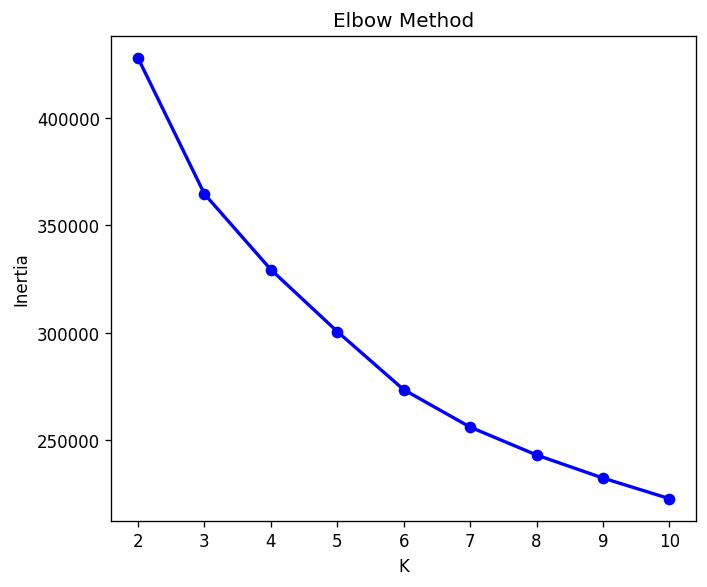

['/content/artifacts/cluster_artifacts.joblib']

In [ ]:
# Soil + weather only -- intentionally NOT including latitude/longitude here,
# so the resulting cluster id is an agro-climatic profile (soil+weather
# signature) rather than a stand-in for "which region is this".
cluster_feature_cols = (
    [f'growing_season_{v}_mean' for v in cfg.weather_vars] +
    [f'growing_season_{v}_sum'  for v in cfg.weather_vars] +
    [f'{v}_depth_averaged_mean' for v in cfg.soil_vars]
)
cluster_feature_cols = [c for c in cluster_feature_cols if c in feat.columns]

X_cluster = feat[cluster_feature_cols].fillna(0).values
scaler_c = StandardScaler()
X_cluster_s = scaler_c.fit_transform(X_cluster)

inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_s)
    inertias.append(km.inertia_)

K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
feat['cluster'] = kmeans.fit_predict(X_cluster_s)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(list(K_range), inertias, 'bo-', linewidth=2)
ax.set_title('Elbow Method'); ax.set_xlabel('K'); ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('/content/clustering_results.png', bbox_inches='tight')
plt.show()

joblib.dump({'scaler': scaler_c, 'kmeans': kmeans, 'feature_cols': cluster_feature_cols},
            f'{ARTIFACT_DIR}/cluster_artifacts.joblib')

##  STEP 7 — Final Feature Set & Temporal Folds

In [ ]:
def build_feature_cols(feat: pd.DataFrame, cfg: CountryConfig) -> list:
    # Soil + micro-climate/weather, plus ONE deliberate exception:
    # years_since_baseline. region_encoded/latitude/longitude are LOCATION
    # identifiers -- categorical/coordinate stand-ins for "which US state is
    # this" that have no meaning in another country's dataset, so they're
    # excluded. years_since_baseline is different: it's a continuous TIME
    # trend (every country has a calendar) that captures real genetic/
    # technology yield improvement over the decades -- a physical driver,
    # not a memorized location. Dropping it left tree models with no way to
    # extrapolate the upward yield trend into later test years, which is why
    # removing it caused R^2 to collapse. 'cluster' is kept because it's
    # built purely from soil+weather signatures (see Step 6) -- not a
    # location proxy.
    cols = (
        [f'growing_season_{v}_mean' for v in cfg.weather_vars] +
        [f'growing_season_{v}_sum'  for v in cfg.weather_vars] +
        [f'growing_season_{v}_std'  for v in cfg.weather_vars] +
        [f'annual_{v}_mean'         for v in cfg.weather_vars] +
        [f'{v}_depth_averaged_mean' for v in cfg.soil_vars] +
        [f'{v}_topsoil_mean'        for v in cfg.soil_vars] +
        ['growing_season_diurnal_temperature_range',
         'growing_season_precipitation_x_solar_radiation',
         'growing_season_vapor_pressure_x_max_temperature',
         'growing_season_heat_stress_degree_days',
         'growing_season_water_balance_proxy',
         'soil_water_holding_proxy',
         'sand_x_low_precipitation',
         'years_since_baseline', 'cluster']
    )
    return [c for c in cols if c in feat.columns]


TARGET = 'yield_kg_ha'
feature_cols = build_feature_cols(feat, cfg)
folds = cfg.fixed_folds

print(f'  Features used: {len(feature_cols)}')
for c in feature_cols:
    print('   -', c)

json.dump({'feature_cols': feature_cols, 'target': TARGET},
          open(f'{ARTIFACT_DIR}/feature_schema.json', 'w'), indent=2)

  Features used: 55
   - growing_season_precipitation_mean
   - growing_season_solar_radiation_mean
   - growing_season_snow_water_equivalent_mean
   - growing_season_maximum_temperature_mean
   - growing_season_minimum_temperature_mean
   - growing_season_vapor_pressure_mean
   - growing_season_precipitation_sum
   - growing_season_solar_radiation_sum
   - growing_season_snow_water_equivalent_sum
   - growing_season_maximum_temperature_sum
   - growing_season_minimum_temperature_sum
   - growing_season_vapor_pressure_sum
   - growing_season_precipitation_std
   - growing_season_solar_radiation_std
   - growing_season_snow_water_equivalent_std
   - growing_season_maximum_temperature_std
   - growing_season_minimum_temperature_std
   - growing_season_vapor_pressure_std
   - annual_precipitation_mean
   - annual_solar_radiation_mean
   - annual_snow_water_equivalent_mean
   - annual_maximum_temperature_mean
   - annual_minimum_temperature_mean
   - annual_vapor_pressure_mean
   - bulk_de

##  STEP 8 — Model Comparison: Ridge, Lasso, Random Forest, Extra Trees, XGBoost

Same 5-fold temporal CV as before, now with **Extra Trees** added alongside
Random Forest and XGBoost. Extra Trees splits on randomly chosen thresholds
(not the locally-optimal ones RF picks), which trades a bit of per-tree fit
for lower variance and faster training — useful here since soil/weather
features are noisy and somewhat collinear.

Model Comparison (5-Fold Temporal CV, sorted by RMSE):


,Model,Mean RMSE (kg/ha),Std RMSE,Mean MAE,Mean R²,Std R²
4,XGBoost,404.57,92.54,327.61,0.5045,0.3730
2,Random Forest,456.53,111.61,382.09,0.3637,0.5021
3,Extra Trees,462.59,110.51,386.31,0.3512,0.5057
0,Ridge,533.43,53.93,437.55,0.2171,0.3526
1,Lasso,534.15,54.59,438.21,0.2146,0.3558


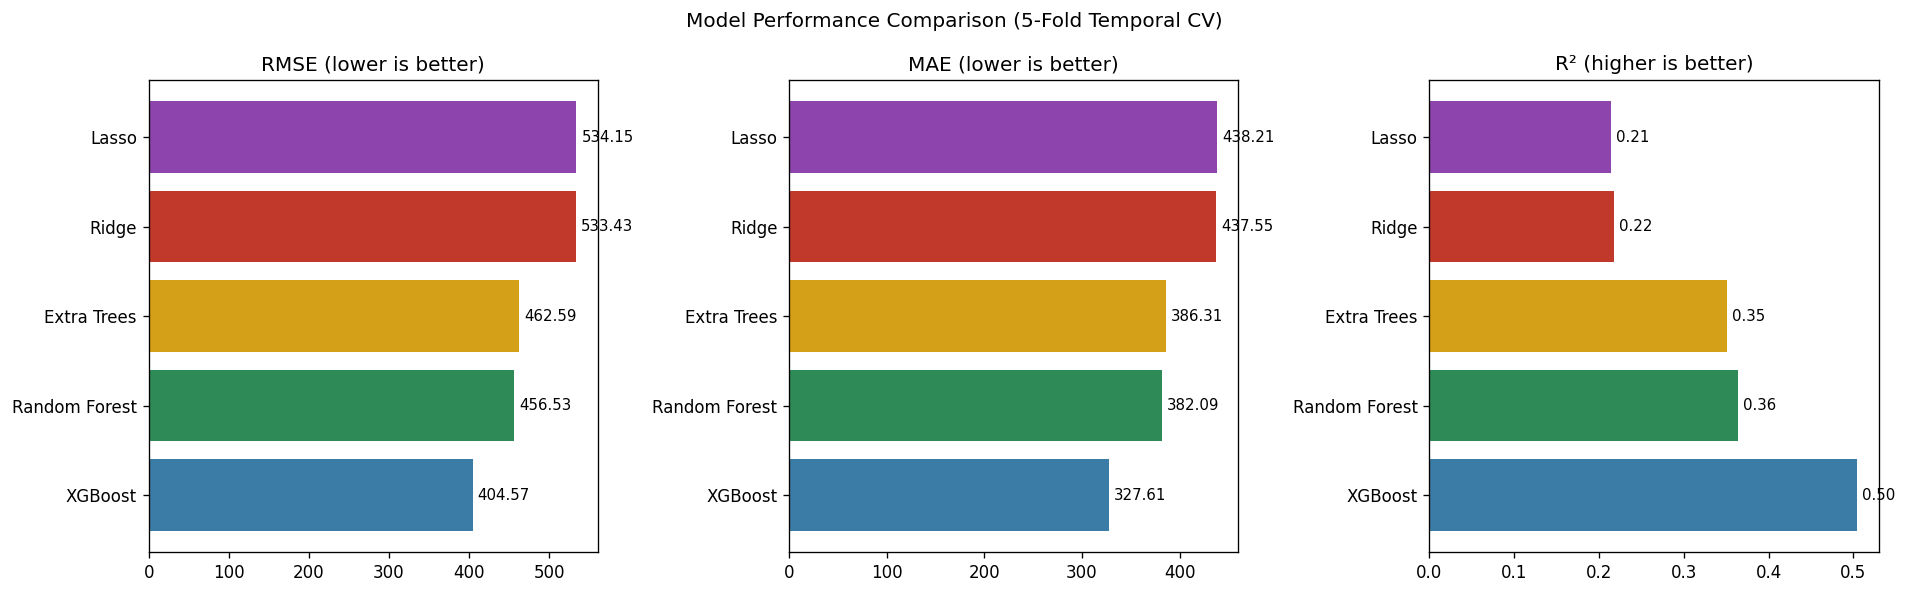

In [ ]:
MODEL_FACTORIES = {
    'Ridge': lambda: Ridge(alpha=1.0),
    'Lasso': lambda: Lasso(alpha=0.01, max_iter=5000),
    'Random Forest': lambda: RandomForestRegressor(
        n_estimators=600, max_depth=16, min_samples_leaf=3,
        max_features=0.4, max_samples=0.85, min_samples_split=6,
        random_state=42, n_jobs=-1),
    'Extra Trees': lambda: ExtraTreesRegressor(
        n_estimators=700, max_depth=18, min_samples_leaf=2,
        max_features=0.5, min_samples_split=4,
        random_state=42, n_jobs=-1),
    'XGBoost': lambda: xgb.XGBRegressor(
        n_estimators=800, max_depth=5, learning_rate=0.02,
        subsample=0.75, colsample_bytree=0.7, colsample_bylevel=0.8,
        min_child_weight=5, gamma=0.1, reg_alpha=0.05, reg_lambda=1.5,
        random_state=42, verbosity=0),
}

all_results = {name: [] for name in MODEL_FACTORIES}

for fold in folds:
    train = feat[feat['obs_year'] <= fold['train_max_year']]
    test  = feat[feat['obs_year'] == fold['test_year']]
    if len(train) == 0 or len(test) == 0:
        continue
    X_train, y_train = train[feature_cols].fillna(0).values, train[TARGET].values
    X_test,  y_test   = test[feature_cols].fillna(0).values,  test[TARGET].values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    for name, factory in MODEL_FACTORIES.items():
        model = factory()
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
        all_results[name].append({
            'rmse': np.sqrt(mean_squared_error(y_test, preds)),
            'mae':  mean_absolute_error(y_test, preds),
            'r2':   r2_score(y_test, preds),
        })

summary_rows = []
for name, results in all_results.items():
    summary_rows.append({
        'Model': name,
        'Mean RMSE (kg/ha)': round(np.mean([r['rmse'] for r in results]), 2),
        'Std RMSE':  round(np.std([r['rmse'] for r in results]), 2),
        'Mean MAE':  round(np.mean([r['mae'] for r in results]), 2),
        'Mean R²':   round(np.mean([r['r2'] for r in results]), 4),
        'Std R²':    round(np.std([r['r2'] for r in results]), 4),
    })
summary_df = pd.DataFrame(summary_rows).sort_values('Mean RMSE (kg/ha)')
print('Model Comparison (5-Fold Temporal CV, sorted by RMSE):')
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_bar = ['#3A7CA5', '#2E8B57', '#D4A017', '#C0392B', '#8E44AD']
for ax, metric, label in zip(
        axes, ['Mean RMSE (kg/ha)', 'Mean MAE', 'Mean R²'],
        ['RMSE (lower is better)', 'MAE (lower is better)', 'R² (higher is better)']):
    bars = ax.barh(summary_df['Model'], summary_df[metric], color=colors_bar[:len(summary_df)])
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(label)
plt.suptitle('Model Performance Comparison (5-Fold Temporal CV)')
plt.tight_layout()
plt.savefig('/content/model_comparison.png', bbox_inches='tight')
plt.show()

##  STEP 9 — Hyperparameter Search on the Tree Ensembles

`RandomizedSearchCV` needs an explicit list of (train_idx, test_idx) pairs to
respect the temporal folds — a plain K-fold would leak future years into
training. `PredefinedTemporalSplit` builds exactly that from `folds`.

In [ ]:
import time

def make_temporal_split_indices(feat: pd.DataFrame, folds: list, feature_cols: list):
    """Yields (train_idx, test_idx) arrays usable as a cv= argument."""
    splits = []
    for fold in folds:
        train_idx = feat.index[feat['obs_year'] <= fold['train_max_year']].to_numpy()
        test_idx  = feat.index[feat['obs_year'] == fold['test_year']].to_numpy()
        if len(train_idx) and len(test_idx):
            splits.append((train_idx, test_idx))
    return splits

X_all = feat[feature_cols].fillna(0).values
y_all = feat[TARGET].values
scaler_all = StandardScaler()
X_all_s = scaler_all.fit_transform(X_all)

# Map original DataFrame index -> positional index expected by sklearn's cv splits
pos_of = {idx: pos for pos, idx in enumerate(feat.index)}
all_temporal_splits = [
    (np.array([pos_of[i] for i in tr]), np.array([pos_of[i] for i in te]))
    for tr, te in make_temporal_split_indices(feat, folds, feature_cols)
]

# Use only the most recent 3 folds for the search itself (full 5-fold CV still
# happens later, in Step 10, on whichever model wins). This alone cuts search
# cost by ~40% and recent years are the most relevant signal for tuning anyway.
search_splits = all_temporal_splits[-3:]
print(f'  Using {len(search_splits)} of {len(all_temporal_splits)} folds for hyperparameter search.')
print(f'  Training rows in largest search fold: {max(len(tr) for tr, _ in search_splits):,}')

# ── Sanity-check timing: fit ONE small model first so you know roughly how
#    long the full search will take before committing to it. ──────────────
_t0 = time.time()
xgb.XGBRegressor(n_estimators=300, max_depth=5, tree_method='hist',
                  n_jobs=1, verbosity=0, random_state=42).fit(
    X_all_s[search_splits[0][0]], y_all[search_splits[0][0]])
_t1 = time.time()
print(f'  Single XGBoost fit (300 trees, 1 fold): {_t1 - _t0:.1f}s -> '
      f'rough full-search estimate: {(_t1 - _t0) * (15 + 12 + 12) * len(search_splits) / 60:.1f} min')

xgb_param_dist = {
    'n_estimators': [200, 300, 400, 600],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.02, 0.03, 0.05, 0.08],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.05, 0.1],
    'reg_lambda': [1.0, 1.5, 2.0],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=1, tree_method='hist'),
    param_distributions=xgb_param_dist, n_iter=15, scoring='neg_root_mean_squared_error',
    cv=search_splits, random_state=42, n_jobs=-1, verbose=2)
t0 = time.time()
xgb_search.fit(X_all_s, y_all)
print(f'  [{time.time()-t0:.0f}s] Best XGBoost params: {xgb_search.best_params_}')
print(f'  Best XGBoost CV RMSE: {-xgb_search.best_score_:.2f} kg/ha')

et_param_dist = {
    'n_estimators': [200, 300, 400, 600],
    'max_depth': [10, 14, 18, None],
    'min_samples_leaf': [2, 3, 5],
    'min_samples_split': [2, 4, 6],
    'max_features': [0.3, 0.4, 0.5],
}
et_search = RandomizedSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=1),
    param_distributions=et_param_dist, n_iter=12, scoring='neg_root_mean_squared_error',
    cv=search_splits, random_state=42, n_jobs=-1, verbose=2)
t0 = time.time()
et_search.fit(X_all_s, y_all)
print(f'\n  [{time.time()-t0:.0f}s] Best Extra Trees params: {et_search.best_params_}')
print(f'  Best Extra Trees CV RMSE: {-et_search.best_score_:.2f} kg/ha')

rf_param_dist = {
    'n_estimators': [200, 300, 400, 600],
    'max_depth': [10, 14, 18, None],
    'min_samples_leaf': [2, 3, 5],
    'min_samples_split': [2, 4, 6],
    'max_features': [0.3, 0.4, 'sqrt'],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=rf_param_dist, n_iter=12, scoring='neg_root_mean_squared_error',
    cv=search_splits, random_state=42, n_jobs=-1, verbose=2)
t0 = time.time()
rf_search.fit(X_all_s, y_all)
print(f'\n  [{time.time()-t0:.0f}s] Best Random Forest params: {rf_search.best_params_}')
print(f'  Best Random Forest CV RMSE: {-rf_search.best_score_:.2f} kg/ha')


  Using 3 of 5 folds for hyperparameter search.
  Training rows in largest search fold: 24,833
  Single XGBoost fit (300 trees, 1 fold): 2.6s -> rough full-search estimate: 5.0 min
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  [94s] Best XGBoost params: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.08, 'colsample_bytree': 0.6}
  Best XGBoost CV RMSE: 427.71 kg/ha
Fitting 3 folds for each of 12 candidates, totalling 36 fits

  [617s] Best Extra Trees params: {'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_depth': None}
  Best Extra Trees CV RMSE: 486.07 kg/ha
Fitting 3 folds for each of 12 candidates, totalling 36 fits

  [2682s] Best Random Forest params: {'n_estimators': 400, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 0.4, 'max_depth': 14}
  Best Random Forest CV RMSE: 472.31 kg/ha


##  STEP 10 — Final Model: Stacked Ensemble

The tuned Extra Trees, Random Forest, and XGBoost from Step 9 become base
learners in a `StackingRegressor`, with Ridge as the meta-learner blending
their outputs. Stacking is evaluated against each tuned model individually
on the same temporal folds, so you can see exactly how much (if any) the
ensemble buys over the single best tree model — if stacking doesn't help on
your data, the comparison table makes that obvious and you can just deploy
the best individual model instead.

In [ ]:
final_candidates = {
    'Extra Trees (tuned)': et_search.best_estimator_,
    'Random Forest (tuned)': rf_search.best_estimator_,
    'XGBoost (tuned)': xgb_search.best_estimator_,
}

stack = StackingRegressor(
    estimators=[
        ('et',  ExtraTreesRegressor(**et_search.best_params_, random_state=42, n_jobs=-1)),
        ('rf',  RandomForestRegressor(**rf_search.best_params_, random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBRegressor(**xgb_search.best_params_, random_state=42, verbosity=0)),
    ],
    final_estimator=Ridge(alpha=1.0),
    passthrough=False, n_jobs=-1)
final_candidates['Stacked Ensemble (ET+RF+XGB -> Ridge)'] = stack

final_results = {name: [] for name in final_candidates}
for fold in folds:
    train = feat[feat['obs_year'] <= fold['train_max_year']]
    test  = feat[feat['obs_year'] == fold['test_year']]
    if len(train) == 0 or len(test) == 0:
        continue
    X_train, y_train = train[feature_cols].fillna(0).values, train[TARGET].values
    X_test,  y_test   = test[feature_cols].fillna(0).values,  test[TARGET].values
    scaler_f = StandardScaler()
    X_train_s, X_test_s = scaler_f.fit_transform(X_train), scaler_f.transform(X_test)

    for name, model in final_candidates.items():
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
        final_results[name].append({
            'rmse': np.sqrt(mean_squared_error(y_test, preds)),
            'mae':  mean_absolute_error(y_test, preds),
            'r2':   r2_score(y_test, preds),
        })

final_summary_rows = [{
    'Model': name,
    'Mean RMSE (kg/ha)': round(np.mean([r['rmse'] for r in res]), 2),
    'Mean MAE': round(np.mean([r['mae'] for r in res]), 2),
    'Mean R²': round(np.mean([r['r2'] for r in res]), 4),
} for name, res in final_results.items()]
final_summary_df = pd.DataFrame(final_summary_rows).sort_values('Mean RMSE (kg/ha)')
print('Final candidates (tuned individual models vs. stacked ensemble):')
display(final_summary_df)

FINAL_MODEL_NAME = final_summary_df.iloc[0]['Model']
print(f"\n   Selected final model: {FINAL_MODEL_NAME}")

# ── Fit the selected final model on ALL data and persist artifacts ──────
final_scaler = StandardScaler()
X_all_s_final = final_scaler.fit_transform(X_all)
final_model = final_candidates[FINAL_MODEL_NAME]
final_model.fit(X_all_s_final, y_all)

joblib.dump(final_model,  f'{ARTIFACT_DIR}/final_model.joblib')
joblib.dump(final_scaler, f'{ARTIFACT_DIR}/final_scaler.joblib')
json.dump({'feature_cols': feature_cols, 'target': TARGET, 'model_name': FINAL_MODEL_NAME},
          open(f'{ARTIFACT_DIR}/final_model_schema.json', 'w'), indent=2)
print(f'  ✓ Final model artifacts saved to {ARTIFACT_DIR}/')

Final candidates (tuned individual models vs. stacked ensemble):


,Model,Mean RMSE (kg/ha),Mean MAE,Mean R²
2,XGBoost (tuned),410.25,332.41,0.5016
3,Stacked Ensemble (ET+RF+XGB -> Ridge),436.50,357.25,0.4248
1,Random Forest (tuned),457.71,382.83,0.3646
0,Extra Trees (tuned),460.74,384.31,0.3582



  🏆 Selected final model: XGBoost (tuned)
  ✓ Final model artifacts saved to /content/artifacts/


##  STEP 11 — Feature Importance & Predicted-vs-Actual (Final Model)

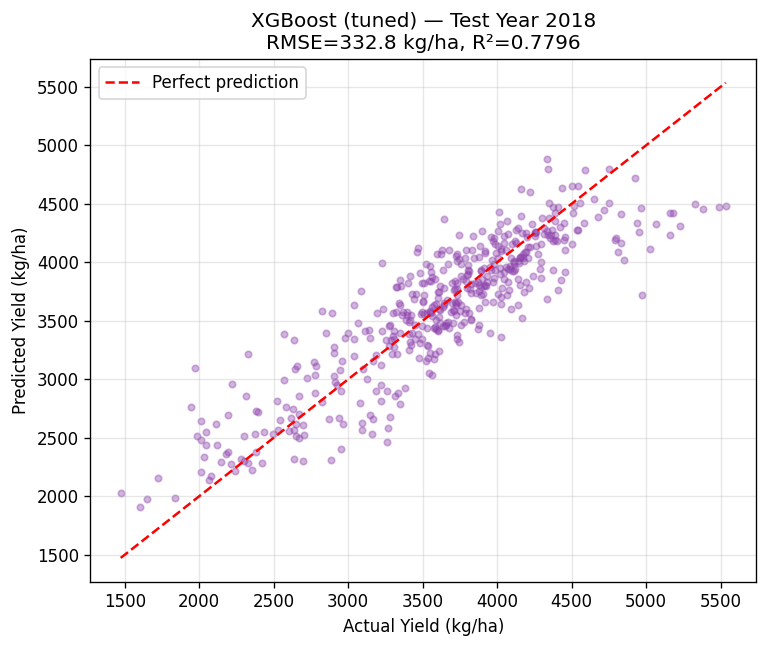

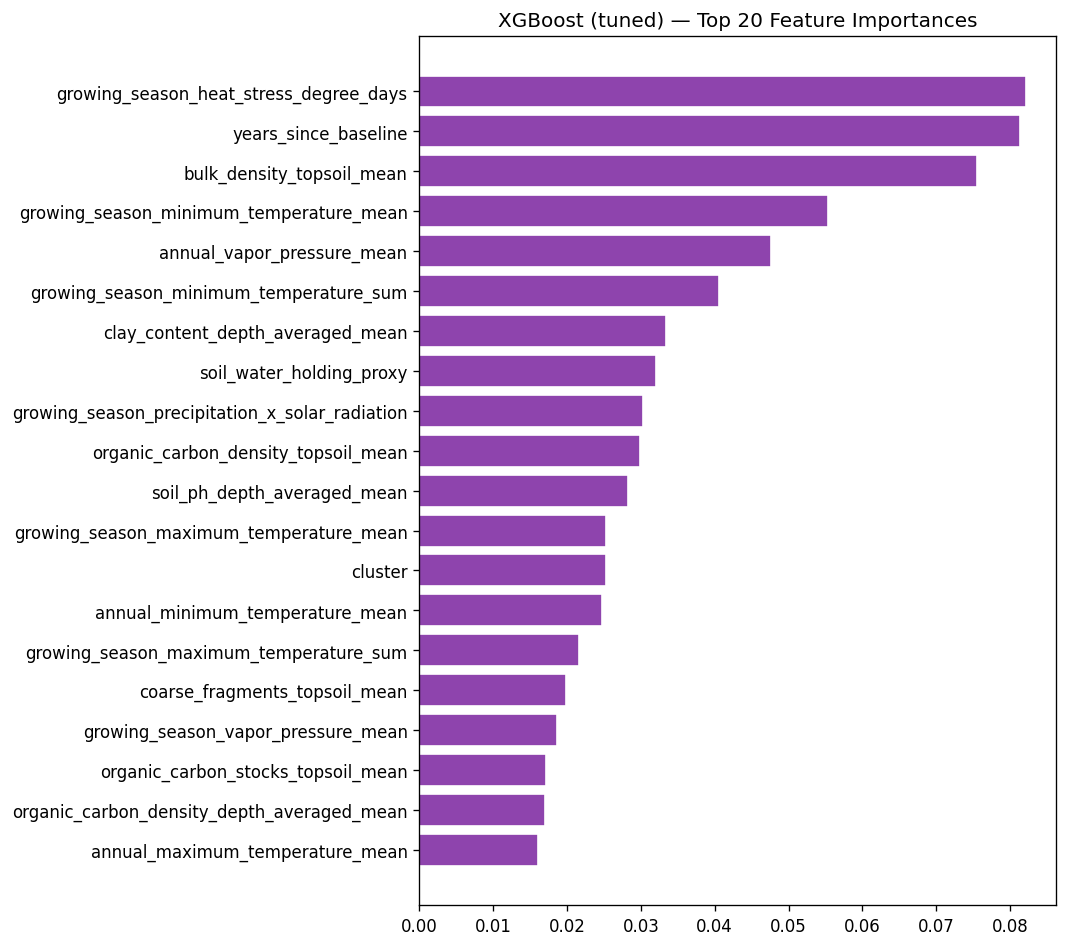


  Top-10 features:


,Importance
growing_season_heat_stress_degree_days,0.082100
years_since_baseline,0.081287
bulk_density_topsoil_mean,0.075559
growing_season_minimum_temperature_mean,0.055319
annual_vapor_pressure_mean,0.047650
growing_season_minimum_temperature_sum,0.040548
clay_content_depth_averaged_mean,0.033425
soil_water_holding_proxy,0.031994
growing_season_precipitation_x_solar_radiation,0.030313
organic_carbon_density_topsoil_mean,0.029847


In [ ]:
best_fold = folds[-1]
train_b = feat[feat['obs_year'] <= best_fold['train_max_year']]
test_b  = feat[feat['obs_year'] == best_fold['test_year']]
scaler_b = StandardScaler()
X_train_bs = scaler_b.fit_transform(train_b[feature_cols].fillna(0).values)
X_test_bs  = scaler_b.transform(test_b[feature_cols].fillna(0).values)
y_train_b, y_test_b = train_b[TARGET].values, test_b[TARGET].values

plot_model = final_candidates[FINAL_MODEL_NAME]
plot_model.fit(X_train_bs, y_train_b)
y_pred_final = plot_model.predict(X_test_bs)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(y_test_b, y_pred_final, alpha=0.4, s=15, color='#8E44AD')
lo, hi = min(y_test_b.min(), y_pred_final.min()), max(y_test_b.max(), y_pred_final.max())
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
rmse, r2 = np.sqrt(mean_squared_error(y_test_b, y_pred_final)), r2_score(y_test_b, y_pred_final)
ax.set_title(f'{FINAL_MODEL_NAME} — Test Year {best_fold["test_year"]}\nRMSE={rmse:.1f} kg/ha, R²={r2:.4f}')
ax.set_xlabel('Actual Yield (kg/ha)'); ax.set_ylabel('Predicted Yield (kg/ha)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/predicted_vs_actual_final.png', bbox_inches='tight')
plt.show()

# ── Feature importance: averaged across tuned ET/RF/XGB if stacked, else native ──
TOP_N = 20
def get_importances(model):
    if hasattr(model, 'feature_importances_'):
        return model.feature_importances_
    if hasattr(model, 'estimators_'):  # StackingRegressor base learners
        imps = [e.feature_importances_ for e in model.estimators_ if hasattr(e, 'feature_importances_')]
        return np.mean(imps, axis=0) if imps else None
    return None

importances = get_importances(final_model)
if importances is not None:
    idx = np.argsort(importances)[-TOP_N:]
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.barh([feature_cols[i] for i in idx], importances[idx], color='#8E44AD', edgecolor='white')
    ax.set_title(f'{FINAL_MODEL_NAME} — Top {TOP_N} Feature Importances')
    plt.tight_layout()
    plt.savefig('/content/feature_importance_final.png', bbox_inches='tight')
    plt.show()

    top10 = pd.Series(importances, index=feature_cols).sort_values(ascending=False).head(10)
    print('\n  Top-10 features:')
    display(top10.to_frame('Importance'))

##  STEP 12 — Final Summary & Download Outputs

In [ ]:
print('=' * 65)
print('PIPELINE COMPLETE')
print('=' * 65)
print(f'\n  Dataset       : {len(feat):,} rows x {feat.shape[1]} columns')
print(f'  Features used : {len(feature_cols)} (soil + micro-climate/weather + location/time)')
print(f'  Clusters (K)  : {K_OPTIMAL}')

print('\n  Model Comparison (Ridge / Lasso / RF / Extra Trees / XGBoost):')
display(summary_df)

print('\n  Tuned candidates vs. stacked ensemble:')
display(final_summary_df)

print(f"\n   Final deployed model: {FINAL_MODEL_NAME}")
best_row = final_summary_df.iloc[0]
print(f"     Mean RMSE : {best_row['Mean RMSE (kg/ha)']} kg/ha")
print(f"     Mean R²   : {best_row['Mean R²']}")

from google.colab import files
output_files = [
    OUTPUT_PATH,
    '/content/eda_overview.png', '/content/clustering_results.png',
    '/content/model_comparison.png', '/content/predicted_vs_actual_final.png',
    '/content/feature_importance_final.png',
    f'{ARTIFACT_DIR}/final_model.joblib', f'{ARTIFACT_DIR}/final_scaler.joblib',
]
for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'  ✓ {f}')

print('\n  ✅ All done!')

PIPELINE COMPLETE

  Dataset       : 25,304 rows x 461 columns
  Features used : 55 (soil + micro-climate/weather + location/time)
  Clusters (K)  : 4

  Model Comparison (Ridge / Lasso / RF / Extra Trees / XGBoost):


,Model,Mean RMSE (kg/ha),Std RMSE,Mean MAE,Mean R²,Std R²
4,XGBoost,404.57,92.54,327.61,0.5045,0.3730
2,Random Forest,456.53,111.61,382.09,0.3637,0.5021
3,Extra Trees,462.59,110.51,386.31,0.3512,0.5057
0,Ridge,533.43,53.93,437.55,0.2171,0.3526
1,Lasso,534.15,54.59,438.21,0.2146,0.3558



  Tuned candidates vs. stacked ensemble:


,Model,Mean RMSE (kg/ha),Mean MAE,Mean R²
2,XGBoost (tuned),410.25,332.41,0.5016
3,Stacked Ensemble (ET+RF+XGB -> Ridge),436.50,357.25,0.4248
1,Random Forest (tuned),457.71,382.83,0.3646
0,Extra Trees (tuned),460.74,384.31,0.3582



  🏆 Final deployed model: XGBoost (tuned)
     Mean RMSE : 410.25 kg/ha
     Mean R²   : 0.5016


...

<IPython.core.display.Javascript object>

  ✓ /content/artifacts/final_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ /content/artifacts/final_scaler.joblib

  ✅ All done!
